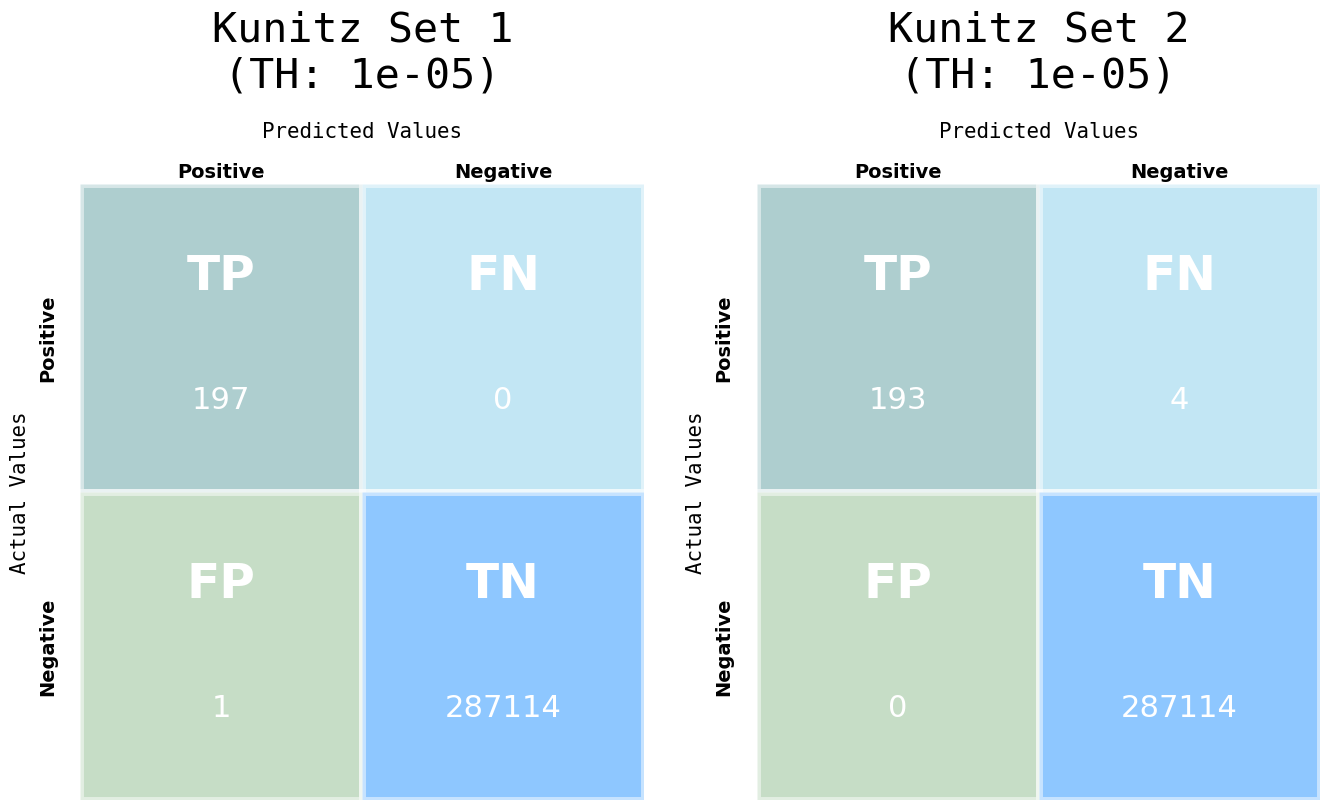

In [59]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pandas as pd

def get_counts(fname, threshold):
    """Calculates TP, FN, FP, TN for a given file and threshold."""
    preds = []
    with open(fname) as fh:
        for line in fh:
            v = line.rstrip().split()
            if len(v) < 3: continue
            preds.append([float(v[1]), int(v[2])]) # E-value and Label
    
    df = pd.DataFrame(preds, columns=['evalue', 'label'])
    df['pred'] = (df['evalue'] <= threshold).astype(int)
    
    tp = len(df[(df['label'] == 1) & (df['pred'] == 1)])
    fn = len(df[(df['label'] == 1) & (df['pred'] == 0)])
    fp = len(df[(df['label'] == 0) & (df['pred'] == 1)])
    tn = len(df[(df['label'] == 0) & (df['pred'] == 0)])
    return tp, fn, fp, tn

def draw_dual_matrices(file1, file2, threshold=1e-05):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    
    datasets = [
        (file1, ax1, "Kunitz Set 1"),
        (file2, ax2, "Kunitz Set 2")
    ]

    for fname, ax, title in datasets:
        tp, fn, fp, tn = get_counts(fname, threshold)
        ax.set_xlim(0, 2)
        ax.set_ylim(0, 2)
        
       
        boxes = [
            (0, 1, 'cadetblue', 'TP', tp), # Top Left (Light Blue)
            (1, 1, 'skyblue', 'FN', fn), # Top Right (Yellow)
            (0, 0, 'darkseagreen', 'FP', fp), # Bottom Left (Yellow)
            (1, 0, 'dodgerblue',  'TN', tn)  # Bottom Right (Dark Blue)
        ]

        for x, y, color, label, val in boxes:
            rect = patches.Rectangle((x, y), 1, 1, linewidth=5, edgecolor='white', facecolor=color, alpha=0.5)
            ax.add_patch(rect)
            ax.text(x+0.5, y+0.7, label, ha='center', va='center', fontsize=35, color='white', fontweight='bold')
            ax.text(x+0.5, y+0.3, f"{val}", ha='center', va='center', fontsize=22, color='white')

        # Labels and Title
        ax.set_title(f'{title}\n(TH: {threshold})',fontfamily='monospace', fontsize=30, pad=70)
        ax.text(1, 2.15, 'Predicted Values', ha='center',fontfamily='monospace', fontsize=15)
        ax.text(-0.25, 1, 'Actual Values', va='center',rotation=90,fontfamily='monospace', fontsize=15)
        ax.text(0.5, 2.02, 'Positive', ha='center', fontsize=14, fontweight='bold')
        ax.text(1.5, 2.02, 'Negative', ha='center', fontsize=14, fontweight='bold')
        ax.text(-0.15, 1.5, 'Positive', va='center', rotation=90, fontsize=14, fontweight='bold')
        ax.text(-0.15, 0.5, 'Negative', va='center', rotation=90, fontsize=14, fontweight='bold')
        ax.axis('off')

    #plt.tight_layout()
    plt.show()


draw_dual_matrices('kunitz_set_1.txt', 'kunitz_set_2.txt', threshold=1e-05)